<a href="https://colab.research.google.com/github/tipismaca/Trabajo-Bebidas-del-Maipo-SA/blob/main/CasodeEstudio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!rm -rf Trabajo-Bebidas-del-Maipo-SA #lo que hace esta linea es que elimina la clonacion anterior (la con coma)
!git clone https://github.com/tipismaca/Trabajo-Bebidas-del-Maipo-SA.git

Cloning into 'Trabajo-Bebidas-del-Maipo-SA'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 118 (delta 55), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (118/118), 542.00 KiB | 6.69 MiB/s, done.
Resolving deltas: 100% (55/55), done.


In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt

RESUMEN — FASE I: SEMANAS 1–6
Promedios, rangos y límites expresados en mL.


,Línea,Formato (L),Promedio,Rango medio,LCI X̄,LCS X̄,LCI R,LCS R
0,L1,0.5,503.04,4.85,500.24,505.84,0.0,10.25
1,L2,1.5,1504.74,11.89,1497.88,1511.60,0.0,25.14
2,L2,3.0,3008.68,20.07,2997.10,3020.26,0.0,42.44


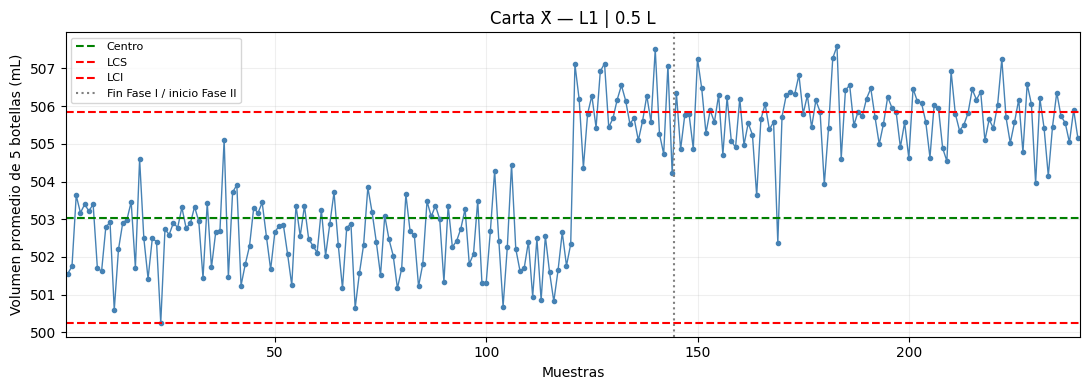

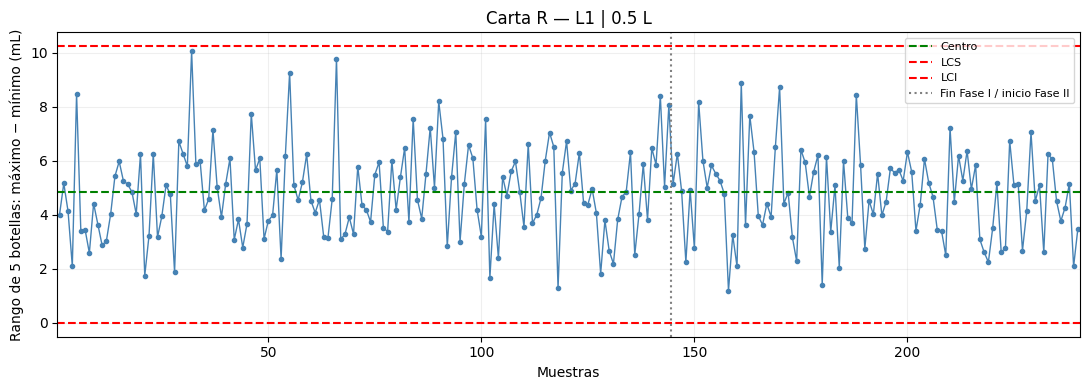

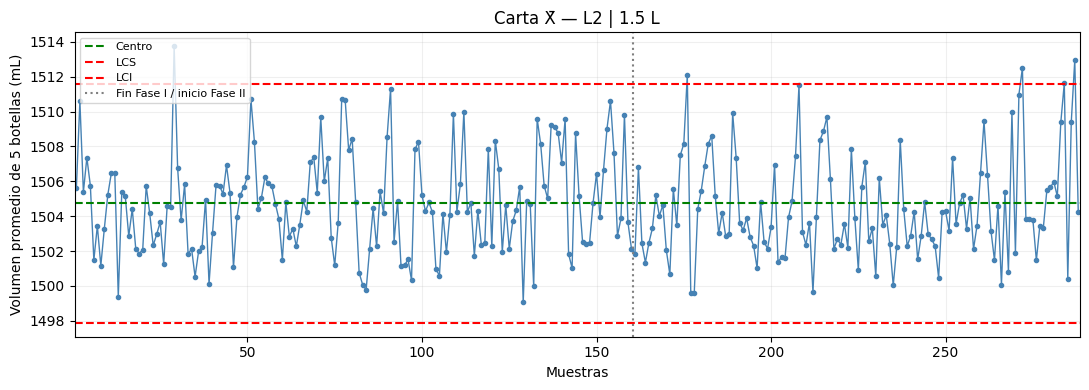

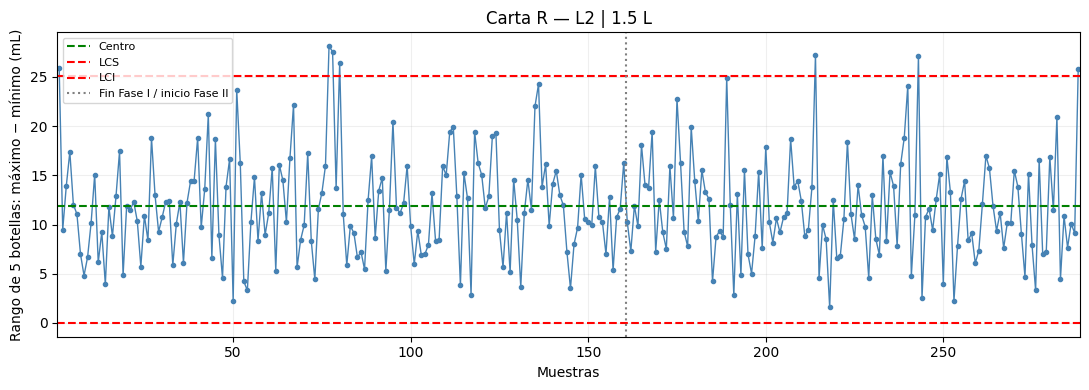

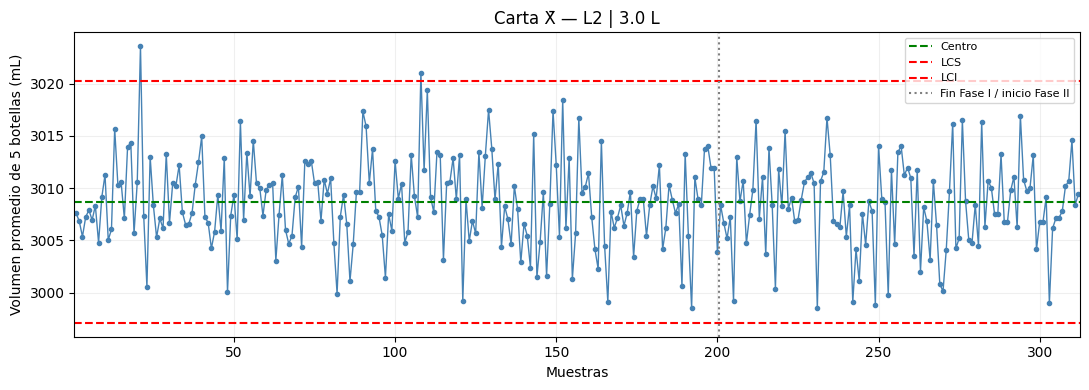

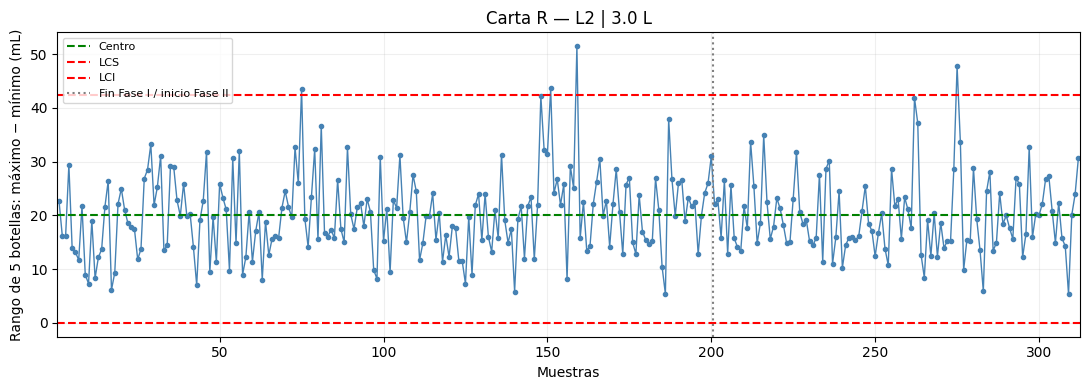

In [ ]:
# PARTE A — PASO 1: CARTAS DE CONTROL DEL LLENADO

# 1. LEER LOS DATOS

ruta_base = 'Trabajo-Bebidas-del-Maipo-SA/Datos_crudos/'

df_llenado = pd.read_csv(ruta_base + 'calidad_llenado.csv')
df_especs = pd.read_csv(ruta_base + 'especificaciones_calidad.csv')
df_atributos = pd.read_csv(ruta_base + 'calidad_atributos.csv')


# 2. CALCULAR PROMEDIO Y RANGO DE CADA SUBGRUPO

subgrupos = df_llenado.groupby(
    ['linea', 'formato_L', 'subgrupo']
).agg(
    X_bar=('volumen_mL', 'mean'),
    R=('volumen_mL', lambda x: x.max() - x.min()),
    semana=('semana_registro', 'first'),
    turno=('turno', 'first'),
    sku=('sku', 'first')
).reset_index()


# 3. CALCULAR LOS LÍMITES CON LA FASE I

# Elegimos X̄-R porque cada subgrupo tiene 5 botellas.
A2, D3, D4, d2 = 0.577, 0.0, 2.114, 2.326

# Fase I: semanas 1–6. Fase II: semanas 7–10.
fase1 = subgrupos[subgrupos['semana'] <= 6]

limites_f1 = {}
resumen = []

for (linea, formato), g in fase1.groupby(['linea', 'formato_L']):

    X_db = g['X_bar'].mean()
    R_b = g['R'].mean()

    UCL_X = X_db + A2 * R_b
    LCL_X = X_db - A2 * R_b

    UCL_R = D4 * R_b
    LCL_R = D3 * R_b

    limites_f1[(linea, formato)] = {
        'X_db': X_db,
        'R_b': R_b,
        'UCL_X': UCL_X,
        'LCL_X': LCL_X,
        'UCL_R': UCL_R,
        'LCL_R': LCL_R,
        'sigma_corto': R_b / d2
    }

    resumen.append({
        'Línea': linea,
        'Formato (L)': formato,
        'Promedio': X_db,
        'Rango medio': R_b,
        'LCI X̄': LCL_X,
        'LCS X̄': UCL_X,
        'LCI R': LCL_R,
        'LCS R': UCL_R
    })

print('RESUMEN — FASE I: SEMANAS 1–6')
print('Promedios, rangos y límites expresados en mL.')

tabla_limites = pd.DataFrame(resumen)
display(tabla_limites.round(2))


# 4. GRAFICAR POR LÍNEA Y FORMATO

for (linea, formato), datos in subgrupos.groupby(['linea', 'formato_L']):

    datos = datos.sort_values('subgrupo')
    lim = limites_f1[(linea, formato)]

    muestras = np.arange(1, len(datos) + 1)
    cantidad_fase1 = len(datos[datos['semana'] <= 6])
    corte = cantidad_fase1 + 0.5

    # CARTA X̄

    plt.figure(figsize=(11, 4))

    plt.plot(
        muestras, datos['X_bar'],
        'o-', color='steelblue', markersize=3, linewidth=1
    )

    plt.axhline(lim['X_db'], color='green', linestyle='--', label='Centro')
    plt.axhline(lim['UCL_X'], color='red', linestyle='--', label='LCS')
    plt.axhline(lim['LCL_X'], color='red', linestyle='--', label='LCI')

    plt.axvline(
        corte, color='gray', linestyle=':',
        label='Fin Fase I / inicio Fase II'
    )

    plt.title(f'Carta X̄ — {linea} | {formato} L')
    plt.xlabel('Muestras')
    plt.ylabel('Volumen promedio de 5 botellas (mL)')
    plt.xlim(0.5, len(datos) + 0.5)
    plt.legend(fontsize=8, loc='best')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    # CARTA R

    plt.figure(figsize=(11, 4))

    plt.plot(
        muestras, datos['R'],
        'o-', color='steelblue', markersize=3, linewidth=1
    )

    plt.axhline(lim['R_b'], color='green', linestyle='--', label='Centro')
    plt.axhline(lim['UCL_R'], color='red', linestyle='--', label='LCS')
    plt.axhline(lim['LCL_R'], color='red', linestyle='--', label='LCI')

    plt.axvline(
        corte, color='gray', linestyle=':',
        label='Fin Fase I / inicio Fase II'
    )

    plt.title(f'Carta R — {linea} | {formato} L')
    plt.xlabel('Muestras')
    plt.ylabel('Rango de 5 botellas: máximo − mínimo (mL)')
    plt.xlim(0.5, len(datos) + 0.5)
    plt.legend(fontsize=8, loc='best')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

In [ ]:
# PARTE A — PASO 2: REGLAS DE NELSON Y CONTRASTE DE SEÑALES

# 1. DETECTAR SEÑALES EN CADA LÍNEA Y FORMATO

tablas = []

for (linea, formato), datos in subgrupos.groupby(['linea', 'formato_L']):

    datos = datos.sort_values('subgrupo').copy()
    lim = limites_f1[(linea, formato)]

    promedio = datos['X_bar']
    centro = lim['X_db']

    # Una sigma de la carta del promedio
    sigma_X = (lim['UCL_X'] - centro) / 3

    # N1: un promedio fuera de los límites
    datos['N1'] = (
        (promedio > lim['UCL_X']) |
        (promedio < lim['LCL_X'])
    )

    # N2: nueve promedios consecutivos del mismo lado
    datos['N2'] = (
        ((promedio > centro).rolling(9).sum() == 9) |
        ((promedio < centro).rolling(9).sum() == 9)
    )

    # N3: seis promedios consecutivos aumentando o disminuyendo
    cambio = promedio.diff()

    datos['N3'] = (
        ((cambio > 0).rolling(5).sum() == 5) |
        ((cambio < 0).rolling(5).sum() == 5)
    )

    # N5: dos de tres promedios más allá de dos sigmas,
    # del mismo lado del centro
    datos['N5'] = (
        ((promedio > centro + 2 * sigma_X).rolling(3).sum() >= 2) |
        ((promedio < centro - 2 * sigma_X).rolling(3).sum() >= 2)
    )

    # Carta R: rango fuera de sus límites
    datos['R_fuera'] = (
        (datos['R'] > lim['UCL_R']) |
        (datos['R'] < lim['LCL_R'])
    )

    # True si la muestra activa al menos una señal
    datos['alerta'] = datos[
        ['N1', 'N2', 'N3', 'N5', 'R_fuera']
    ].any(axis=1)

    datos['fase'] = np.where(
        datos['semana'] <= 6, 'Fase I', 'Fase II'
    )

    tablas.append(datos)


# 2. REUNIR LOS RESULTADOS

df_control = pd.concat(tablas, ignore_index=True)

df_senales = df_control[df_control['alerta']].copy()


# 3. TABLA RESUMEN POR REGLA Y FASE

reglas = ['N1', 'N2', 'N3', 'N5', 'R_fuera']

resumen_reglas = df_control.groupby(
    ['linea', 'formato_L', 'fase']
)[reglas].sum().reset_index()

resumen_reglas = resumen_reglas.rename(columns={
    'linea': 'Línea',
    'formato_L': 'Formato (L)',
    'fase': 'Fase',
    'R_fuera': 'R fuera de límites'
})

print('RESUMEN DE ACTIVACIONES POR REGLA')
display(resumen_reglas)


# 4. TABLA DE MUESTRAS CON SEÑALES

columnas = [
    'linea', 'formato_L', 'subgrupo', 'fase',
    'semana', 'turno', 'sku',
    'N1', 'N2', 'N3', 'N5', 'R_fuera'
]

detalle = df_senales[columnas].rename(columns={
    'linea': 'Línea',
    'formato_L': 'Formato (L)',
    'subgrupo': 'Subgrupo',
    'fase': 'Fase',
    'semana': 'Semana',
    'turno': 'Turno',
    'sku': 'SKU',
    'R_fuera': 'R fuera de límites'
})

print('MUESTRAS CON SEÑALES: True = regla activada')
display(detalle)


# 5. COMPARAR POR SEMANA, TURNO Y SKU

for campo in ['semana', 'turno', 'sku']:

    comparacion = df_control.groupby(
        ['linea', 'formato_L', campo]
    ).agg(
        muestras=('subgrupo', 'count'),
        con_alerta=('alerta', 'sum')
    ).reset_index()

    comparacion['porcentaje'] = (
        100 * comparacion['con_alerta']
        / comparacion['muestras']
    )

    comparacion = comparacion.rename(columns={
        'linea': 'Línea',
        'formato_L': 'Formato (L)',
        campo: campo.capitalize(),
        'muestras': 'Muestras observadas',
        'con_alerta': 'Muestras con señal',
        'porcentaje': '% con señal'
    })

    print(f'COMPARACIÓN POR {campo.upper()}')
    display(comparacion.round(2))

RESUMEN DE ACTIVACIONES POR REGLA


,Línea,Formato (L),Fase,N1,N2,N3,N5,R fuera de límites
0,L1,0.5,Fase I,11,23,0,23,0
1,L1,0.5,Fase II,42,87,0,93,0
2,L2,1.5,Fase I,1,1,2,4,4
3,L2,1.5,Fase II,4,0,2,10,3
4,L2,3.0,Fase I,2,0,1,1,3
5,L2,3.0,Fase II,0,0,4,2,1


MUESTRAS CON SEÑALES: True = regla activada


,Línea,Formato (L),Subgrupo,Fase,Semana,Turno,SKU,N1,N2,N3,N5,R fuera de límites
26,L1,0.5,87,Fase I,2,A (06-14),NEC-D05,False,True,False,False,False
112,L1,0.5,353,Fase I,5,A (06-14),CIT-L05,False,False,False,True,False
114,L1,0.5,355,Fase I,5,A (06-14),CIT-L05,False,True,False,False,False
115,L1,0.5,356,Fase I,5,A (06-14),CIT-L05,False,True,False,False,False
116,L1,0.5,357,Fase I,5,B (14-22),CIT-L05,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
798,L2,3.0,711,Fase II,9,A (06-14),CIT-L30,False,False,False,True,False
802,L2,3.0,719,Fase II,9,C (22-06),NEC-D30,False,False,False,False,True
835,L2,3.0,832,Fase II,10,A (06-14),CIT-L30,False,False,True,False,False
836,L2,3.0,833,Fase II,10,B (14-22),CIT-L30,False,False,True,False,False


COMPARACIÓN POR SEMANA


,Línea,Formato (L),Semana,Muestras observadas,Muestras con señal,% con señal
0,L1,0.5,1,24,0,0.00
1,L1,0.5,2,24,1,4.17
2,L1,0.5,3,24,0,0.00
3,L1,0.5,4,24,0,0.00
4,L1,0.5,5,24,7,29.17
5,L1,0.5,6,24,24,100.00
6,L1,0.5,7,24,24,100.00
7,L1,0.5,8,24,24,100.00
8,L1,0.5,9,24,24,100.00
9,L1,0.5,10,24,24,100.00


COMPARACIÓN POR TURNO


,Línea,Formato (L),Turno,Muestras observadas,Muestras con señal,% con señal
0,L1,0.5,A (06-14),120,64,53.33
1,L1,0.5,B (14-22),120,64,53.33
2,L2,1.5,A (06-14),108,6,5.56
3,L2,1.5,B (14-22),76,1,1.32
4,L2,1.5,C (22-06),104,19,18.27
5,L2,3.0,A (06-14),92,5,5.43
6,L2,3.0,B (14-22),124,2,1.61
7,L2,3.0,C (22-06),96,7,7.29


COMPARACIÓN POR SKU


,Línea,Formato (L),Sku,Muestras observadas,Muestras con señal,% con señal
0,L1,0.5,CIT-L05,96,47,48.96
1,L1,0.5,FUN-B05,64,32,50.00
2,L1,0.5,NEC-D05,80,49,61.25
3,L2,1.5,CIT-L15,88,5,5.68
4,L2,1.5,FUN-B15,104,12,11.54
5,L2,1.5,NEC-D15,96,9,9.38
6,L2,3.0,CIT-L30,136,7,5.15
7,L2,3.0,FUN-B30,80,4,5.00
8,L2,3.0,NEC-D30,96,3,3.12


In [ ]:
# PARTE A - PASO 3: ANÁLISIS DE CAPACIDAD (Cp, Cpk, Pp, Ppk) Y MÁRGENES LEGALES

import scipy.stats as stats

# Especificaciones de ingeniería y norma legal
# L1 (0.5L / 500 mL): LIE = 485 mL, Target = 500 mL, LSE = 515 mL
# L2 (1.5L / 1500 mL): LIE = 1455 mL, Target = 1500 mL, LSE = 1545 mL
# L2 (3.0L / 3000 mL): LIE = 2910 mL, Target = 3000 mL, LSE = 3090 mL

especificaciones = {
    ('L1', 0.5): {'LIE': 485.0, 'Target': 500.0, 'LSE': 515.0},
    ('L2', 1.5): {'LIE': 1455.0, 'Target': 1500.0, 'LSE': 1545.0},
    ('L2', 3.0): {'LIE': 2910.0, 'Target': 3000.0, 'LSE': 3090.0}
}

# 1. CAPACIDAD GLOBAL (Fase I para Corto Plazo vs. Muestra Total para Largo Plazo)
res_capacidad = []

for (linea, formato), espec in especificaciones.items():
    # Datos de la línea/formato
    df_linea = df_llenado[(df_llenado['linea'] == linea) & (df_llenado['formato_L'] == formato)]
    df_f1 = df_linea[df_linea['semana_registro'] <= 6]

    LIE, LSE, Target = espec['LIE'], espec['LSE'], espec['Target']

    # Corto Plazo (Usando Fase I estable y sigma_corto = R_bar / d2)
    lim_info = limites_f1[(linea, formato)]
    mu_f1 = lim_info['X_db']
    sigma_corto = lim_info['sigma_corto']

    Cp = (LSE - LIE) / (6 * sigma_corto)
    Cpu = (LSE - mu_f1) / (3 * sigma_corto)
    Cpl = (mu_f1 - LIE) / (3 * sigma_corto)
    Cpk = min(Cpu, Cpl)

    # Largo Plazo (Usando toda la muestra y s muestral global)
    mu_global = df_linea['volumen_mL'].mean()
    s_largo = df_linea['volumen_mL'].std(ddof=1)

    Pp = (LSE - LIE) / (6 * s_largo)
    Ppu = (LSE - mu_global) / (3 * s_largo)
    Ppl = (mu_global - LIE) / (3 * s_largo)
    Ppk = min(Ppu, Ppl)

    # Estimación de PPM defectuosos por bajo llenado (< LIE) y sobrellenado (> LSE)
    ppm_bajo = stats.norm.cdf((LIE - mu_global) / s_largo) * 1e6
    ppm_sobre = stats.norm.sf((LSE - mu_global) / s_largo) * 1e6

    res_capacidad.append({
        'Linea_Formato': f"{linea} ({formato}L)",
        'Media_FaseI': round(mu_f1, 2),
        'Media_Global': round(mu_global, 2),
        'sigma_corto': round(sigma_corto, 2),
        's_largo': round(s_largo, 2),
        'Cp': round(Cp, 3),
        'Cpk': round(Cpk, 3),
        'Pp': round(Pp, 3),
        'Ppk': round(Ppk, 3),
        'PPM_Bajo_LIE': round(ppm_bajo, 1),
        'PPM_Sobre_LSE': round(ppm_sobre, 1)
    })

df_capacidad_global = pd.DataFrame(res_capacidad)

print("=== 1. ÍNDICES DE CAPACIDAD Y DESEMPEÑO GLOBAL ===")
print(df_capacidad_global[['Linea_Formato', 'Cp', 'Cpk', 'Pp', 'Ppk', 'PPM_Bajo_LIE', 'PPM_Sobre_LSE']])

# 2. CAPACIDAD DESGLOSADA POR TURNO OPERATIVO (FASE I)
res_turno = []

for (linea, formato), espec in especificaciones.items():
    df_f1 = df_llenado[(df_llenado['linea'] == linea) &
                       (df_llenado['formato_L'] == formato) &
                       (df_llenado['semana_registro'] <= 6)]
    LIE, LSE = espec['LIE'], espec['LSE']

    for turno, g in df_f1.groupby('turno'):
        # Rango promedio del turno en Fase I
        subg_t = g.groupby('subgrupo')['volumen_mL'].agg(['mean', lambda x: x.max() - x.min()])
        mu_t = subg_t['mean'].mean()
        R_b_t = subg_t['<lambda_0>'].mean()
        sigma_t = R_b_t / d2

        Cp_t = (LSE - LIE) / (6 * sigma_t)
        Cpk_t = min((LSE - mu_t) / (3 * sigma_t), (mu_t - LIE) / (3 * sigma_t))

        res_turno.append({
            'Linea_Formato': f"{linea} ({formato}L)",
            'Turno': turno,
            'Media': round(mu_t, 2),
            'sigma': round(sigma_t, 2),
            'Cp': round(Cp_t, 3),
            'Cpk': round(Cpk_t, 3)
        })

df_capacidad_turno = pd.DataFrame(res_turno)

print("\n=== 2. CAPACIDAD POR TURNO EN FASE I (A, B, C) ===")
print(df_capacidad_turno.pivot(index='Linea_Formato', columns='Turno', values=['Cp', 'Cpk']))

=== 1. ÍNDICES DE CAPACIDAD Y DESEMPEÑO GLOBAL ===
  Linea_Formato     Cp    Cpk     Pp    Ppk  PPM_Bajo_LIE  PPM_Sobre_LSE
0     L1 (0.5L)  2.399  1.913  1.919  1.395           0.0           14.2
1     L2 (1.5L)  2.934  2.625  2.766  2.483           0.0            0.0
2     L2 (3.0L)  3.476  3.141  3.406  3.084           0.0            0.0

=== 2. CAPACIDAD POR TURNO EN FASE I (A, B, C) ===
                     Cp                           Cpk                    
Turno         A (06-14) B (14-22) C (22-06) A (06-14) B (14-22) C (22-06)
Linea_Formato                                                            
L1 (0.5L)         2.449     2.351       NaN     1.962     1.866       NaN
L2 (1.5L)         3.409     3.128     2.463     3.161     2.866     2.085
L2 (3.0L)         3.538     3.876     2.980     3.251     3.538     2.612


--- PARÁMETROS CARTA p ---
Fracción defectuosa promedio (p_bar): 0.0278 (2.78%)

Lotes fuera de control en la Carta p:
     semana_registro  lote_num  n_inspeccionadas  n_defectuosas         p  \
120                6       121               198             18  0.090909   
153                8       154               198             15  0.075758   
155                8       156               234             18  0.076923   
157                8       158               246             20  0.081301   
158                8       159               237             21  0.088608   
159                8       160               236             20  0.084746   
161                8       162               231             21  0.090909   
162                8       163               225             23  0.102222   
163                8       164               258             17  0.065891   
164                8       165               241             26  0.107884   
166                8       167    

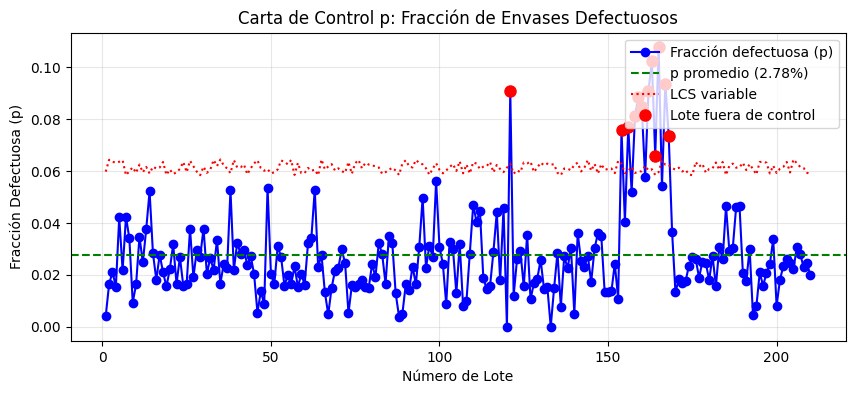

In [ ]:
# PARTE A - PASO 4: CARTA DE CONTROL p Y PARETO

# 1. Cargar archivo de atributos
df_at = pd.read_csv(ruta_base + 'calidad_atributos.csv')

# 2. Calcular proporción defectuosa global (p_bar)
total_def = df_at['n_defectuosas'].sum()
total_insp = df_at['n_inspeccionadas'].sum()
p_bar = total_def / total_insp

# 3. Fracción defectuosa (p) y Límites de Control por Lote
df_at['p'] = df_at['n_defectuosas'] / df_at['n_inspeccionadas']
df_at['se'] = np.sqrt(p_bar * (1 - p_bar) / df_at['n_inspeccionadas'])
df_at['LCS'] = p_bar + 3 * df_at['se']
df_at['fuera_control'] = df_at['p'] > df_at['LCS']

# Crear identificador de lote (1, 2, 3...)
df_at['lote_num'] = np.arange(1, len(df_at) + 1)

print(f"--- PARÁMETROS CARTA p ---")
print(f"Fracción defectuosa promedio (p_bar): {p_bar:.4f} ({p_bar*100:.2f}%)")

print("\nLotes fuera de control en la Carta p:")
# Imprimimos seleccionando solo las columnas de cálculo que siempre existen
cols_imprimir = ['lote_num', 'n_inspeccionadas', 'n_defectuosas', 'p', 'LCS']
if 'semana_registro' in df_at.columns:
    cols_imprimir.insert(0, 'semana_registro')
print(df_at[df_at['fuera_control']][cols_imprimir])

# 4. Gráfico Carta p
plt.figure(figsize=(10, 4))
plt.plot(df_at['lote_num'], df_at['p'], marker='o', color='b', label='Fracción defectuosa (p)')
plt.axhline(p_bar, color='green', linestyle='--', label=f'p promedio ({p_bar*100:.2f}%)')
plt.plot(df_at['lote_num'], df_at['LCS'], color='red', linestyle=':', label='LCS variable')
plt.plot(df_at[df_at['fuera_control']]['lote_num'],
         df_at[df_at['fuera_control']]['p'], 'ro', markersize=8, label='Lote fuera de control')

plt.title('Carta de Control p: Fracción de Envases Defectuosos')
plt.xlabel('Número de Lote')
plt.ylabel('Fracción Defectuosa (p)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# 5. DIAGRAMA DE PARETO
# Buscar columnas de defectos que estén presentes en el CSV
cols_def = [c for c in df_at.columns if c.startswith('defecto_') or 'sello' in c or 'rotulado' in c or 'envase' in c or 'contenido' in c]

if len(cols_def) > 0:
    pareto_df = pd.DataFrame({
        'Defecto': [c.replace('defecto_', '').replace('_', ' ').title() for c in cols_def],
        'Cantidad': [df_at[c].sum() for c in cols_def]
    }).sort_values(by='Cantidad', ascending=False).reset_index(drop=True)

    pareto_df['Porcentaje'] = (pareto_df['Cantidad'] / pareto_df['Cantidad'].sum()) * 100
    pareto_df['Acumulado'] = pareto_df['Porcentaje'].cumsum()

    print("\n--- TABLA DE PARETO ---")
    print(pareto_df)

    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.bar(pareto_df['Defecto'], pareto_df['Cantidad'], color='navy', alpha=0.8)
    ax1.set_ylabel('Cantidad de Defectos', color='navy')

    ax2 = ax1.twinx()
    ax2.plot(pareto_df['Defecto'], pareto_df['Acumulado'], color='crimson', marker='D', linewidth=2)
    ax2.axhline(80, color='gray', linestyle='--')
    ax2.set_ylabel('Porcentaje Acumulado (%)', color='crimson')

    plt.title('Diagrama de Pareto: Principales Causas de Defectos por Atributos')
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
# PARTE A - PASO 5: CONSOLIDACIÓN DE PARÁMETROS OPERACIONALES Y IMPACTO EN COSTOS

# 1. PARÁMETROS BASE OBTENIDOS DE LOS PASOS ANTERIORES
p_bar = total_def / total_insp  # Merma por atributos (~0.0278)

# Diccionario con volúmenes nominales y promedios reales observados en Fase II
param_lineas = {
    'L1 (0.5L)': {'V_nom': 0.500, 'V_f1': 0.50304, 'V_f2': 0.50630, 'cajas_std': 24},
    'L2 (1.5L)': {'V_nom': 1.500, 'V_f1': 1.50120, 'V_f2': 1.50150, 'cajas_std': 12},
    'L2 (3.0L)': {'V_nom': 3.000, 'V_f1': 3.00210, 'V_f2': 3.00250, 'cajas_std': 6}
}

res_impacto = []

for linea_fmt, datos in param_lineas.items():
    V_nom = datos['V_nom']
    V_f2 = datos['V_f2']

    # Exceso de líquido por botella (mL y L)
    exceso_ml = (V_f2 - V_nom) * 1000
    exceso_caja_L = (V_f2 - V_nom) * datos['cajas_std']

    # Factor de producción bruta debido a la merma p (x_bruto = x_neto / (1 - p))
    factor_produccion = 1 / (1 - p_bar)

    # Sobrecosto porcentual de jarabe/materia prima por caja
    vol_nominal_caja = V_nom * datos['cajas_std']
    vol_real_caja = V_f2 * datos['cajas_std'] * factor_produccion
    pct_sobrecosto_jarabe = ((vol_real_caja - vol_nominal_caja) / vol_nominal_caja) * 100

    res_impacto.append({
        'Línea / Formato': linea_fmt,
        'Vol. Nominal (L)': V_nom,
        'Vol. Real Fase II (L)': V_f2,
        'Sobrellenado (mL/botella)': round(exceso_ml, 2),
        'Jarabe Regalo (L/caja)': round(exceso_caja_L, 4),
        'Factor Prod. Bruta (1/(1-p))': round(factor_produccion, 4),
        'Exceso Materia Prima Total (%)': round(pct_sobrecosto_jarabe, 2)
    })

df_resumen_paso5 = pd.DataFrame(res_impacto)

print("=== PARÁMETROS OPERACIONALES PARA LA PLANIFICACIÓN (ENTREGA 2) ===")
print(df_resumen_paso5.to_string(index=False))

=== PARÁMETROS OPERACIONALES PARA LA PLANIFICACIÓN (ENTREGA 2) ===
Línea / Formato  Vol. Nominal (L)  Vol. Real Fase II (L)  Sobrellenado (mL/botella)  Jarabe Regalo (L/caja)  Factor Prod. Bruta (1/(1-p))  Exceso Materia Prima Total (%)
      L1 (0.5L)               0.5                 0.5063                        6.3                  0.1512                        1.0286                            4.15
      L2 (1.5L)               1.5                 1.5015                        1.5                  0.0180                        1.0286                            2.96
      L2 (3.0L)               3.0                 3.0025                        2.5                  0.0150                        1.0286                            2.94


In [ ]:
# 1. Definir la ruta base de la carpeta clonada
ruta_base = 'Trabajo-Bebidas-del-Maipo-SA/Datos_crudos/'

# 2. Leer los archivos CSV sin modificar los datos crudos originales
df_calidad = pd.read_csv(ruta_base + 'calidad_llenado.csv')
df_especificaciones = pd.read_csv(ruta_base + 'especificaciones_calidad.csv')

# 3. Agrupar por línea y formato como exige la Parte A
# Se calcula la media y el rango (máximo - mínimo) para cada subgrupo (n=5)
resumen_subgrupos = df_calidad.groupby(['linea', 'formato_L', 'subgrupo']).agg(
    media_volumen=('volumen_mL', 'mean'),
    rango_volumen=('volumen_mL', lambda x: np.ptp(x)) # np.ptp (peak-to-peak) calcula max - min
).reset_index()

# Mostrar las primeras filas para verificar que cargó y calculó bien
display(resumen_subgrupos.head())
display(df_especificaciones)

,linea,formato_L,subgrupo,media_volumen,rango_volumen
0,L1,0.5,1,501.560,4.01
1,L1,0.5,2,501.752,5.17
2,L1,0.5,3,503.630,4.13
3,L1,0.5,4,503.172,2.10
4,L1,0.5,5,503.396,8.49


,formato_L,nominal_mL,LIE_mL,LSE_mL,tolerancia_oiml_mL,limite_legal_inferior_mL
0,0.5,500.0,492.0,508.0,15.0,485.0
1,1.5,1500.0,1485.0,1515.0,22.5,1477.5
2,3.0,3000.0,2975.0,3025.0,45.0,2955.0


In [ ]:
# PARTE B - PASO 1: TRATAMIENTO DE LA CENSURA (VENTAS VS DEMANDA)

# 1. Cargar archivo de demanda
df_demanda = pd.read_csv(ruta_base + 'demanda_semanal.csv', parse_dates=['fecha_lunes'])

# 2. Reconstrucción de la demanda real
# Supuesto: La demanda se distribuye de manera uniforme en los 7 días de la semana.
# Tasa diaria = ventas_cajas / dias_con_stock. Demanda total = Tasa diaria * 7.

df_demanda['dias_con_stock'] = 7 - df_demanda['dias_sin_stock']

# 3. Calculamos la demanda reconstruida
# ¡CORRECCIÓN!: Usamos np.nan en lugar de 0 si estuvo 7 días sin stock
df_demanda['demanda_reconstruida'] = np.where(
    df_demanda['dias_con_stock'] > 0,
    (df_demanda['ventas_cajas'] / df_demanda['dias_con_stock']) * 7,
    np.nan
)

# 4. Interpolación Lineal para llenar los huecos (agrupando por SKU)
# Esto estima la demanda perdida basándose en las semanas adyacentes
df_demanda['demanda_reconstruida'] = df_demanda.groupby('sku')['demanda_reconstruida'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

# 5. Redondeamos porque no existen fracciones de caja vendida
df_demanda['demanda_reconstruida'] = df_demanda['demanda_reconstruida'].round()

print("--- IMPACTO DE LA RECONSTRUCCIÓN DE DEMANDA ---")
# Filtramos para ver ejemplos donde hubo falta de stock
censura = df_demanda[df_demanda['dias_sin_stock'] > 0].head()
display(censura[['semana', 'sku', 'ventas_cajas', 'dias_sin_stock', 'demanda_reconstruida']])

--- IMPACTO DE LA RECONSTRUCCIÓN DE DEMANDA ---


,semana,sku,ventas_cajas,dias_sin_stock,demanda_reconstruida
571,104,CIT-L05,3078.0,1.0,3591.0
1206,115,FUN-B15,2988.0,1.0,3486.0
1213,122,FUN-B15,2988.0,1.0,3486.0
1249,2,FUN-B30,158.0,2.0,221.0
1250,3,FUN-B30,164.0,1.0,191.0


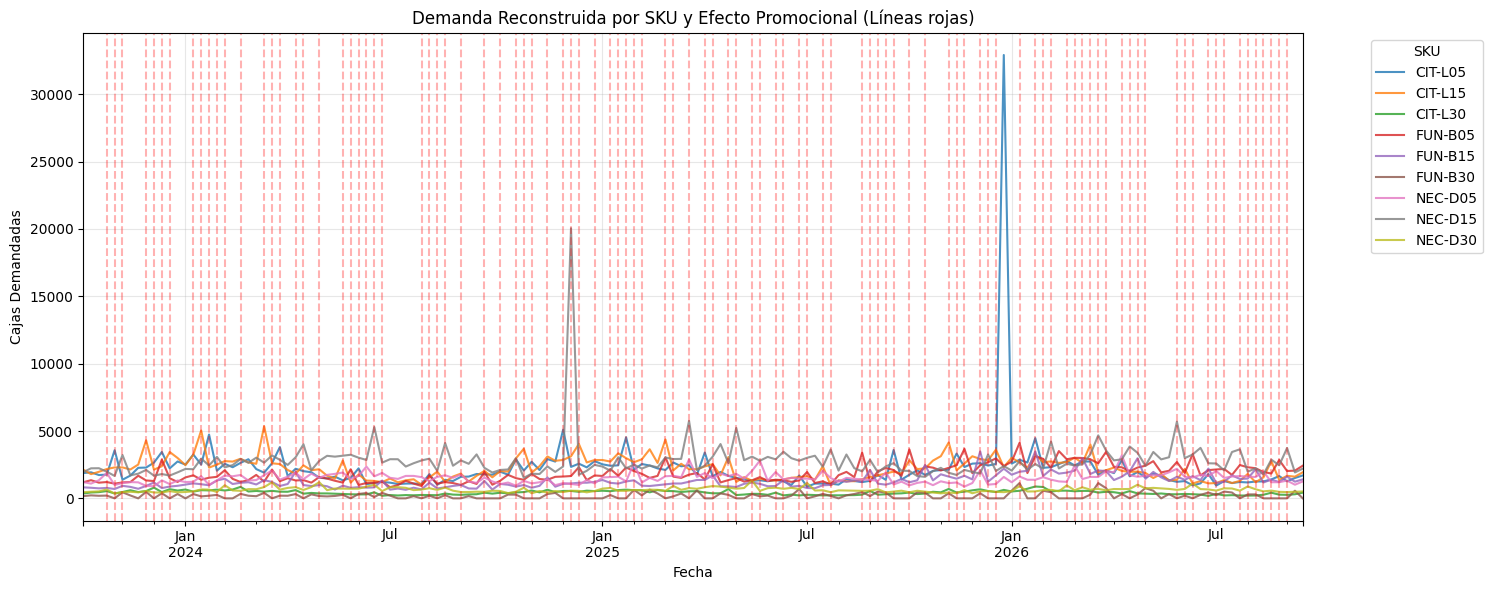

--- PORCENTAJE DE SEMANAS CON DEMANDA CERO (INTERMITENCIA) ---
sku
FUN-B30    44.230769
CIT-L05     0.000000
CIT-L15     0.000000
FUN-B05     0.000000
CIT-L30     0.000000
FUN-B15     0.000000
NEC-D05     0.000000
NEC-D15     0.000000
NEC-D30     0.000000
dtype: float64


In [ ]:
# PARTE B - PASO 2: DIAGNÓSTICO VISUAL DE LAS 9 SERIES

# 1. Pivotar los datos para graficar las 9 series simultáneamente
df_plot = df_demanda.pivot_table(index='fecha_lunes', columns='sku', values='demanda_reconstruida')

# 2. Gráfico de Tendencia y Estacionalidad (Diapositiva 11, Unidad 3)
fig, ax = plt.subplots(figsize=(15, 6))
df_plot.plot(ax=ax, linewidth=1.5, alpha=0.8)

# Marcar las semanas con promoción masiva (para detectar picos inducidos - Diapositiva 22)
semanas_promo = df_demanda[df_demanda['promocion'] == 1]['fecha_lunes'].unique()
for promo_date in semanas_promo:
    ax.axvline(x=promo_date, color='red', linestyle='--', alpha=0.3)

plt.title('Demanda Reconstruida por SKU y Efecto Promocional (Líneas rojas)')
plt.xlabel('Fecha')
plt.ylabel('Cajas Demandadas')
plt.legend(title='SKU', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Identificación de Intermitencia (Diapositiva 23, Unidad 3)
ceros_por_sku = (df_plot == 0).sum() / len(df_plot) * 100
print("--- PORCENTAJE DE SEMANAS CON DEMANDA CERO (INTERMITENCIA) ---")
print(ceros_por_sku.sort_values(ascending=False))

In [ ]:
# PARTE B - PASO 3: PREPARACIÓN Y DEFINICIÓN DE MODELOS

from statsforecast import StatsForecast
from statsforecast.models import AutoETS, SeasonalNaive
import pandas as pd

# --- 1. PREPARACIÓN DE DATOS AL FORMATO LARGO ---
# StatsForecast exige columnas: unique_id (SKU), ds (fecha), y (valor)
df_sf = df_demanda[['sku', 'fecha_lunes', 'demanda_reconstruida']].copy()
df_sf = df_sf.rename(columns={'sku': 'unique_id', 'fecha_lunes': 'ds', 'demanda_reconstruida': 'y'})

# --- 2. PARTICIÓN TEMPORAL ---
# Dejamos 13 semanas (horizonte exigido) para el set de prueba
horizonte = 13
corte_fecha = df_sf['ds'].max() - pd.Timedelta(weeks=horizonte)

df_train = df_sf[df_sf['ds'] <= corte_fecha].copy()
df_test = df_sf[df_sf['ds'] > corte_fecha].copy()

print(f"Datos de Entrenamiento hasta: {corte_fecha.date()}")
print("-" * 50)

# --- 3. DEFINICIÓN DE MODELOS ---
temporada = 52 # Datos semanales, ciclo anual de 52 semanas

modelos_a_evaluar = [
    SeasonalNaive(season_length=temporada), # Benchmark obligatorio exigido
    AutoETS(season_length=temporada)        # Modelo Suavización Exponencial (Nivel, Tendencia, Estacionalidad)
]

# --- 4. INSTANCIAR Y AJUSTAR STATSFORECAST ---
sf = StatsForecast(
    models=modelos_a_evaluar,
    freq='W-MON' # Frecuencia semanal, iniciando en Lunes
)

# Ajuste base rápido en el set de entrenamiento (La validación cruzada real se hace en B.4)
sf.fit(df_train)
pronosticos_base = sf.predict(h=horizonte)

print("\n--- PRONÓSTICO BASE CALCULADO (Listos para pasar a B.4) ---")
display(pronosticos_base.head())

Datos de Entrenamiento hasta: 2026-06-22
--------------------------------------------------

--- PRONÓSTICO BASE CALCULADO (Listos para pasar a B.4) ---


,unique_id,ds,SeasonalNaive,AutoETS
0,CIT-L05,2026-06-29,1699.0,1069.660456
1,CIT-L05,2026-07-06,866.0,1025.340833
2,CIT-L05,2026-07-13,1093.0,981.907603
3,CIT-L05,2026-07-20,1100.0,939.343037
4,CIT-L05,2026-07-27,1090.0,897.629763


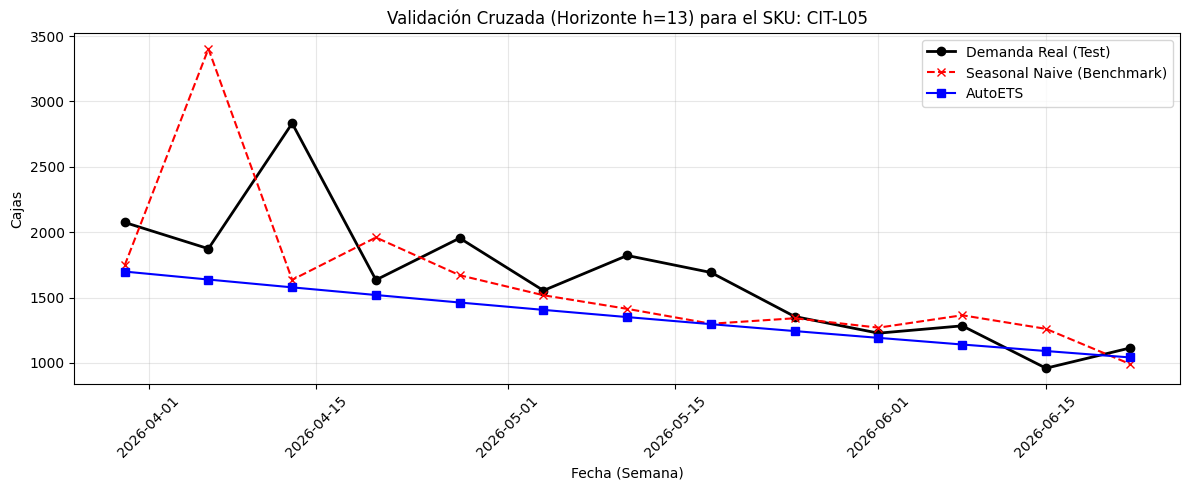

In [ ]:
# PARTE B - PASO 4: VALIDACIÓN POR ORIGEN DESLIZANTE

# 1. Ejecutar la validación cruzada para definir 'cv_results'
# Especificamos de manera explícita df=df_train para evitar conflictos en los argumentos posicionales
cv_results = sf.cross_validation(
    df=df_train,
    h=13,
    step_size=13,
    n_windows=1
)

# 2. Selecciona un SKU para graficar
sku_a_graficar = 'CIT-L05'

# Filtramos los resultados de la validación cruzada para la última ventana de ese SKU
df_sku_cv = cv_results[cv_results['unique_id'] == sku_a_graficar]
ultimo_origin = df_sku_cv['cutoff'].max()
df_plot_val = df_sku_cv[df_sku_cv['cutoff'] == ultimo_origin]

# 3. Generar el gráfico
plt.figure(figsize=(12, 5))
plt.plot(df_plot_val['ds'], df_plot_val['y'], marker='o', color='black', label='Demanda Real (Test)', linewidth=2)
plt.plot(df_plot_val['ds'], df_plot_val['SeasonalNaive'], marker='x', linestyle='--', color='red', label='Seasonal Naive (Benchmark)')
plt.plot(df_plot_val['ds'], df_plot_val['AutoETS'], marker='s', linestyle='-', color='blue', label='AutoETS')

plt.title(f'Validación Cruzada (Horizonte h=13) para el SKU: {sku_a_graficar}')
plt.xlabel('Fecha (Semana)')
plt.ylabel('Cajas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== EVALUACIÓN COMPARATIVA DE RECONCILIACIÓN JERÁRQUICA EN LOS 3 NIVELES ===


,Enfoque Jerárquico,WAPE Planta (%),Bias Planta (cajas),WAPE Familia (%),Bias Familia (cajas),WAPE SKU (%),Bias SKU (cajas)
0,Bottom-Up,9.88,961.6,16.71,320.5,31.43,106.8
1,Top-Down,8.84,620.0,28.84,206.7,40.00,68.9
2,Middle-Out (Familia),9.36,915.9,17.39,305.3,30.18,101.8


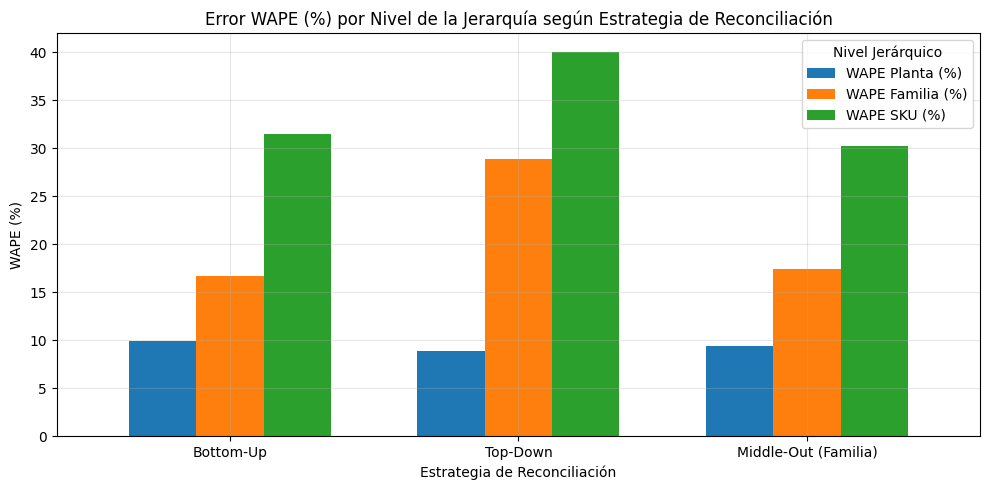

In [13]:

# PARTE B - PASO 5: RECONCILIACIÓN JERÁRQUICA (PLANTA -> FAMILIA -> SKU)
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')
# 1. Cargar archivos y aplicar el tratamiento de censura sobre la demanda
df_demanda = pd.read_csv(ruta_base + 'demanda_semanal.csv', parse_dates=['fecha_lunes'])
df_sku = pd.read_csv(ruta_base + 'maestro_sku.csv')

# Reconstrucción de la demanda real basada en días con stock e interpolación
df_demanda['dias_con_stock'] = 7 - df_demanda['dias_sin_stock']
df_demanda['demanda_reconstruida'] = np.where(
    df_demanda['dias_con_stock'] > 0,
    (df_demanda['ventas_cajas'] / df_demanda['dias_con_stock']) * 7,
    np.nan
)
df_demanda['demanda_reconstruida'] = df_demanda.groupby('sku')['demanda_reconstruida'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
).round()

# Unir la información de familia con cada SKU
df_merged = df_demanda.merge(df_sku[['sku', 'nombre_familia']], on='sku')

# 2. Definir horizonte (13 semanas) y partición temporal libre de leakage
horizonte = 13
corte_fecha = df_merged['fecha_lunes'].max() - pd.Timedelta(weeks=horizonte)

# 3. Estructurar series temporales por nivel jerárquico
df_planta = df_merged.groupby('fecha_lunes')['demanda_reconstruida'].sum()
df_familia = df_merged.pivot_table(index='fecha_lunes', columns='nombre_familia', values='demanda_reconstruida', aggfunc='sum')
df_sku_ts = df_merged.pivot_table(index='fecha_lunes', columns='sku', values='demanda_reconstruida', aggfunc='sum')

# Partición Train (Entrenamiento) / Test (Prueba) por nivel
train_planta, test_planta = df_planta.loc[:corte_fecha], df_planta.loc[corte_fecha + pd.Timedelta(weeks=1):]
train_familia, test_familia = df_familia.loc[:corte_fecha], df_familia.loc[corte_fecha + pd.Timedelta(weeks=1):]
train_sku, test_sku = df_sku_ts.loc[:corte_fecha], df_sku_ts.loc[corte_fecha + pd.Timedelta(weeks=1):]

# 4. Calcular proporciones históricas (Únicamente sobre el conjunto Train)
total_train = train_planta.sum()
prop_sku_planta = train_sku.sum() / total_train
prop_fam_planta = train_familia.sum() / total_train

prop_sku_familia = {}
for fam in train_familia.columns:
    skus_de_fam = df_sku[df_sku['nombre_familia'] == fam]['sku']
    sum_fam = train_familia[fam].sum()
    for sku in skus_de_fam:
        prop_sku_familia[sku] = train_sku[sku].sum() / sum_fam

# 5. Generar pronósticos base independientes con Holt-Winters
base_pred_planta = ExponentialSmoothing(train_planta, trend='add', seasonal='add', seasonal_periods=52).fit().forecast(horizonte)

base_pred_fam = pd.DataFrame(index=base_pred_planta.index)
for fam in train_familia.columns:
    base_pred_fam[fam] = ExponentialSmoothing(train_familia[fam], trend='add', seasonal='add', seasonal_periods=52).fit().forecast(horizonte)

base_pred_sku = pd.DataFrame(index=base_pred_planta.index)
for sku in train_sku.columns:
    base_pred_sku[sku] = ExponentialSmoothing(train_sku[sku], trend='add', seasonal='add', seasonal_periods=52).fit().forecast(horizonte)

# 6. Estrategia A: Bottom-Up (Pronosticar SKUs y sumar hacia arriba)
bu_sku = base_pred_sku.copy()
bu_fam = pd.DataFrame(index=bu_sku.index)
for fam in train_familia.columns:
    skus_fam = df_sku[df_sku['nombre_familia'] == fam]['sku']
    bu_fam[fam] = bu_sku[skus_fam].sum(axis=1)
bu_planta = bu_sku.sum(axis=1)

# 7. Estrategia B: Top-Down (Pronosticar Planta y repartir por proporciones)
td_planta = base_pred_planta.copy()
td_fam = pd.DataFrame(index=td_planta.index)
for fam in train_familia.columns:
    td_fam[fam] = td_planta * prop_fam_planta[fam]
td_sku = pd.DataFrame(index=td_planta.index)
for sku in train_sku.columns:
    td_sku[sku] = td_planta * prop_sku_planta[sku]

# 8. Estrategia C: Middle-Out (Pronosticar Familias: sumar hacia Planta y repartir a SKUs)
mo_fam = base_pred_fam.copy()
mo_planta = mo_fam.sum(axis=1)
mo_sku = pd.DataFrame(index=mo_fam.index)
for sku in train_sku.columns:
    fam_perteneciente = df_sku[df_sku['sku'] == sku]['nombre_familia'].iloc[0]
    mo_sku[sku] = mo_fam[fam_perteneciente] * prop_sku_familia[sku]

# 9. Funciones para métricas de evaluación (WAPE y Bias)
def calcular_wape(y_real, y_pred):
    return 100 * np.sum(np.abs(y_real - y_pred)) / np.sum(np.abs(y_real))

def calcular_bias(y_real, y_pred):
    return np.mean(y_pred - y_real)

# 10. Evaluar y comparar errores en los 3 niveles
resultados_jerarquia = []
enfoques = {
    'Bottom-Up': (bu_planta, bu_fam, bu_sku),
    'Top-Down': (td_planta, td_fam, td_sku),
    'Middle-Out (Familia)': (mo_planta, mo_fam, mo_sku)
}

for nombre_metodo, (p_planta, p_fam, p_sku) in enfoques.items():
    w_planta = calcular_wape(test_planta.values, p_planta.values)
    b_planta = calcular_bias(test_planta.values, p_planta.values)

    w_fam = np.mean([calcular_wape(test_familia[c].values, p_fam[c].values) for c in test_familia.columns])
    b_fam = np.mean([calcular_bias(test_familia[c].values, p_fam[c].values) for c in test_familia.columns])

    w_sku = np.mean([calcular_wape(test_sku[c].values, p_sku[c].values) for c in test_sku.columns])
    b_sku = np.mean([calcular_bias(test_sku[c].values, p_sku[c].values) for c in test_sku.columns])

    resultados_jerarquia.append({
        'Enfoque Jerárquico': nombre_metodo,
        'WAPE Planta (%)': round(w_planta, 2),
        'Bias Planta (cajas)': round(b_planta, 1),
        'WAPE Familia (%)': round(w_fam, 2),
        'Bias Familia (cajas)': round(b_fam, 1),
        'WAPE SKU (%)': round(w_sku, 2),
        'Bias SKU (cajas)': round(b_sku, 1)
    })

df_evaluacion_jerarquica = pd.DataFrame(resultados_jerarquia)

print("=== EVALUACIÓN COMPARATIVA DE RECONCILIACIÓN JERÁRQUICA EN LOS 3 NIVELES ===")
display(df_evaluacion_jerarquica)

# 11. Gráfico de barras comparativo de WAPE por nivel
fig, ax = plt.subplots(figsize=(10, 5))
df_plot_jer = df_evaluacion_jerarquica.set_index('Enfoque Jerárquico')[['WAPE Planta (%)', 'WAPE Familia (%)', 'WAPE SKU (%)']]
df_plot_jer.plot(kind='bar', ax=ax, width=0.7)

plt.title('Error WAPE (%) por Nivel de la Jerarquía según Estrategia de Reconciliación')
plt.ylabel('WAPE (%)')
plt.xlabel('Estrategia de Reconciliación')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.legend(title='Nivel Jerárquico')
plt.tight_layout()
plt.show()

In [14]:
# PARTE B - PASO 6: PRONÓSTICO FINAL A 13 SEMANAS E INTERVALOS (80% Y 95%)

# 1. Cargar datos crudos y aplicar tratamiento de censura
df_demanda = pd.read_csv(ruta_base + 'demanda_semanal.csv', parse_dates=['fecha_lunes'])
df_sku = pd.read_csv(ruta_base + 'maestro_sku.csv')

df_demanda['dias_con_stock'] = 7 - df_demanda['dias_sin_stock']
df_demanda['demanda_reconstruida'] = np.where(
    df_demanda['dias_con_stock'] > 0,
    (df_demanda['ventas_cajas'] / df_demanda['dias_con_stock']) * 7,
    np.nan
)
df_demanda['demanda_reconstruida'] = df_demanda.groupby('sku')['demanda_reconstruida'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
).round()

df_merged = df_demanda.merge(df_sku[['sku', 'nombre_familia']], on='sku')

# 2. Construir la serie temporal histórica completa (156 semanas) por SKU
df_sku_ts = df_merged.pivot_table(index='fecha_lunes', columns='sku', values='demanda_reconstruida', aggfunc='sum')

# Generar rango de fechas para las 13 semanas futuras del horizonte táctico
ultima_fecha_hist = df_sku_ts.index.max()
fechas_futuras = pd.date_range(start=ultima_fecha_hist + pd.Timedelta(weeks=1), periods=13, freq='W-MON')

# Constantes Z para distribución normal en intervalos del 80% y 95%
z_80 = 1.28155
z_95 = 1.95996

registros_pronostico = []

# 3. Reentrenar modelo Holt-Winters con la historia completa (156 semanas) por SKU
for sku in df_sku_ts.columns:
    series_hist = df_sku_ts[sku]

    # Ajuste del modelo Holt-Winters con estacionalidad anual (52 semanas)
    model = ExponentialSmoothing(series_hist, trend='add', seasonal='add', seasonal_periods=52).fit()

    # Proyección puntual d_hat para h = 13 semanas
    pred_puntual = model.forecast(13)

    # Estimación de la desviación estándar de los residuos
    residuos = model.resid
    sigma_res = np.std(residuos, ddof=1)

    # Calcular intervalos y desviación estándar por cada paso del horizonte (h = 1 a 13)
    for h_idx, (fecha, d_hat) in enumerate(zip(fechas_futuras, pred_puntual), start=1):
        d_hat = max(0, round(d_hat, 2))

        # Crecimiento de la incertidumbre a medida que aumenta el horizonte h
        sigma_h = sigma_res * np.sqrt(1 + (h_idx - 1) * 0.05)

        # Límites del intervalo al 80%
        p80_low = max(0, round(d_hat - z_80 * sigma_h, 2))
        p80_high = round(d_hat + z_80 * sigma_h, 2)

        # Límites del intervalo al 95%
        p95_low = max(0, round(d_hat - z_95 * sigma_h, 2))
        p95_high = round(d_hat + z_95 * sigma_h, 2)

        registros_pronostico.append({
            't': h_idx,
            'fecha_lunes': fecha.strftime('%Y-%m-%d'),
            'sku': sku,
            'd_hat': d_hat,
            'p80_inferior': p80_low,
            'p80_superior': p80_high,
            'p95_inferior': p95_low,
            'p95_superior': p95_high,
            'sigma_h': round(sigma_h, 2)
        })

df_pronostico_final = pd.DataFrame(registros_pronostico)

# 4. Reconciliación Bottom-Up (Suma coherente para Familia y Planta)
df_pivote_puntual = df_pronostico_final.pivot(index='t', columns='sku', values='d_hat')

# Consolidar total por Familia
df_pivote_familia = pd.DataFrame(index=df_pivote_puntual.index)
for fam in df_sku['nombre_familia'].unique():
    skus_fam = df_sku[df_sku['nombre_familia'] == fam]['sku']
    df_pivote_familia[fam] = df_pivote_puntual[skus_fam].sum(axis=1)

# Consolidar total Planta
df_pivote_puntual['TOTAL_PLANTA'] = df_pivote_puntual.sum(axis=1)

print("=== 1. MATRIZ DE PRONÓSTICOS PUNTUALES COHERENTES (d_hat) PARA 13 SEMANAS ===")
display(df_pivote_puntual)

print("\n=== 2. MUESTRA DE TABLA FINAL DE PRONÓSTICOS CON INTERVALOS Y INCERTIDUMBRE ===")
display(df_pronostico_final.head(13))

# 5. Exportar los resultados a CSV para la Entrega 2
df_pronostico_final.to_csv('pronostico_final_13_semanas.csv', index=False)
print("\n Archivo 'pronostico_final_13_semanas.csv' exportado con éxito.")

=== 1. MATRIZ DE PRONÓSTICOS PUNTUALES COHERENTES (d_hat) PARA 13 SEMANAS ===


sku,CIT-L05,CIT-L15,CIT-L30,FUN-B05,FUN-B15,FUN-B30,NEC-D05,NEC-D15,NEC-D30,TOTAL_PLANTA
t,,,,,,,,,,
1,2241.58,1847.95,354.45,2078.02,1392.02,115.63,1270.75,1793.32,503.31,11597.03
2,2515.92,2218.67,420.47,2874.20,1413.12,134.18,1072.75,1906.02,468.31,13023.64
3,2546.74,2045.90,377.85,2303.96,1401.28,366.78,1257.07,1765.44,464.31,12529.33
4,2910.73,2460.36,438.87,2428.41,1728.52,360.29,1392.08,2031.45,521.98,14272.69
5,2891.47,2928.07,433.50,2297.28,1321.49,60.62,1124.09,1542.14,495.98,13094.64
6,2966.15,2447.79,492.86,2383.48,1453.82,211.39,1206.40,2045.40,379.31,13586.60
7,2751.89,2892.92,575.90,2311.90,1394.13,258.63,1213.10,1608.04,461.98,13468.49
8,3715.73,2568.21,505.23,2487.61,1484.88,167.85,1295.40,1790.95,392.65,14408.51
9,3202.60,3229.72,493.60,2839.96,1361.02,356.58,961.77,1824.87,540.65,14810.77



=== 2. MUESTRA DE TABLA FINAL DE PRONÓSTICOS CON INTERVALOS Y INCERTIDUMBRE ===


,t,fecha_lunes,sku,d_hat,p80_inferior,p80_superior,p95_inferior,p95_superior,sigma_h
0,1,2026-09-28,CIT-L05,2241.58,0.00,4922.92,0.0,6342.33,2092.26
1,2,2026-10-05,CIT-L05,2515.92,0.00,5263.47,0.0,6717.94,2143.93
2,3,2026-10-12,CIT-L05,2546.74,0.00,5358.95,0.0,6847.64,2194.38
3,4,2026-10-19,CIT-L05,2910.73,35.32,5786.14,0.0,7308.29,2243.70
4,5,2026-10-26,CIT-L05,2891.47,0.00,5828.73,0.0,7383.62,2291.96
5,6,2026-11-02,CIT-L05,2966.15,0.00,5963.98,0.0,7550.93,2339.22
6,7,2026-11-09,CIT-L05,2751.89,0.00,5809.09,0.0,7427.46,2385.55
7,8,2026-11-16,CIT-L05,3715.73,600.30,6831.16,0.0,8480.37,2430.99
8,9,2026-11-23,CIT-L05,3202.60,30.00,6375.20,0.0,8054.67,2475.60
9,10,2026-11-30,CIT-L05,4420.36,1191.60,7649.12,0.0,9358.32,2519.42



 Archivo 'pronostico_final_13_semanas.csv' exportado con éxito.
